In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Sample 1

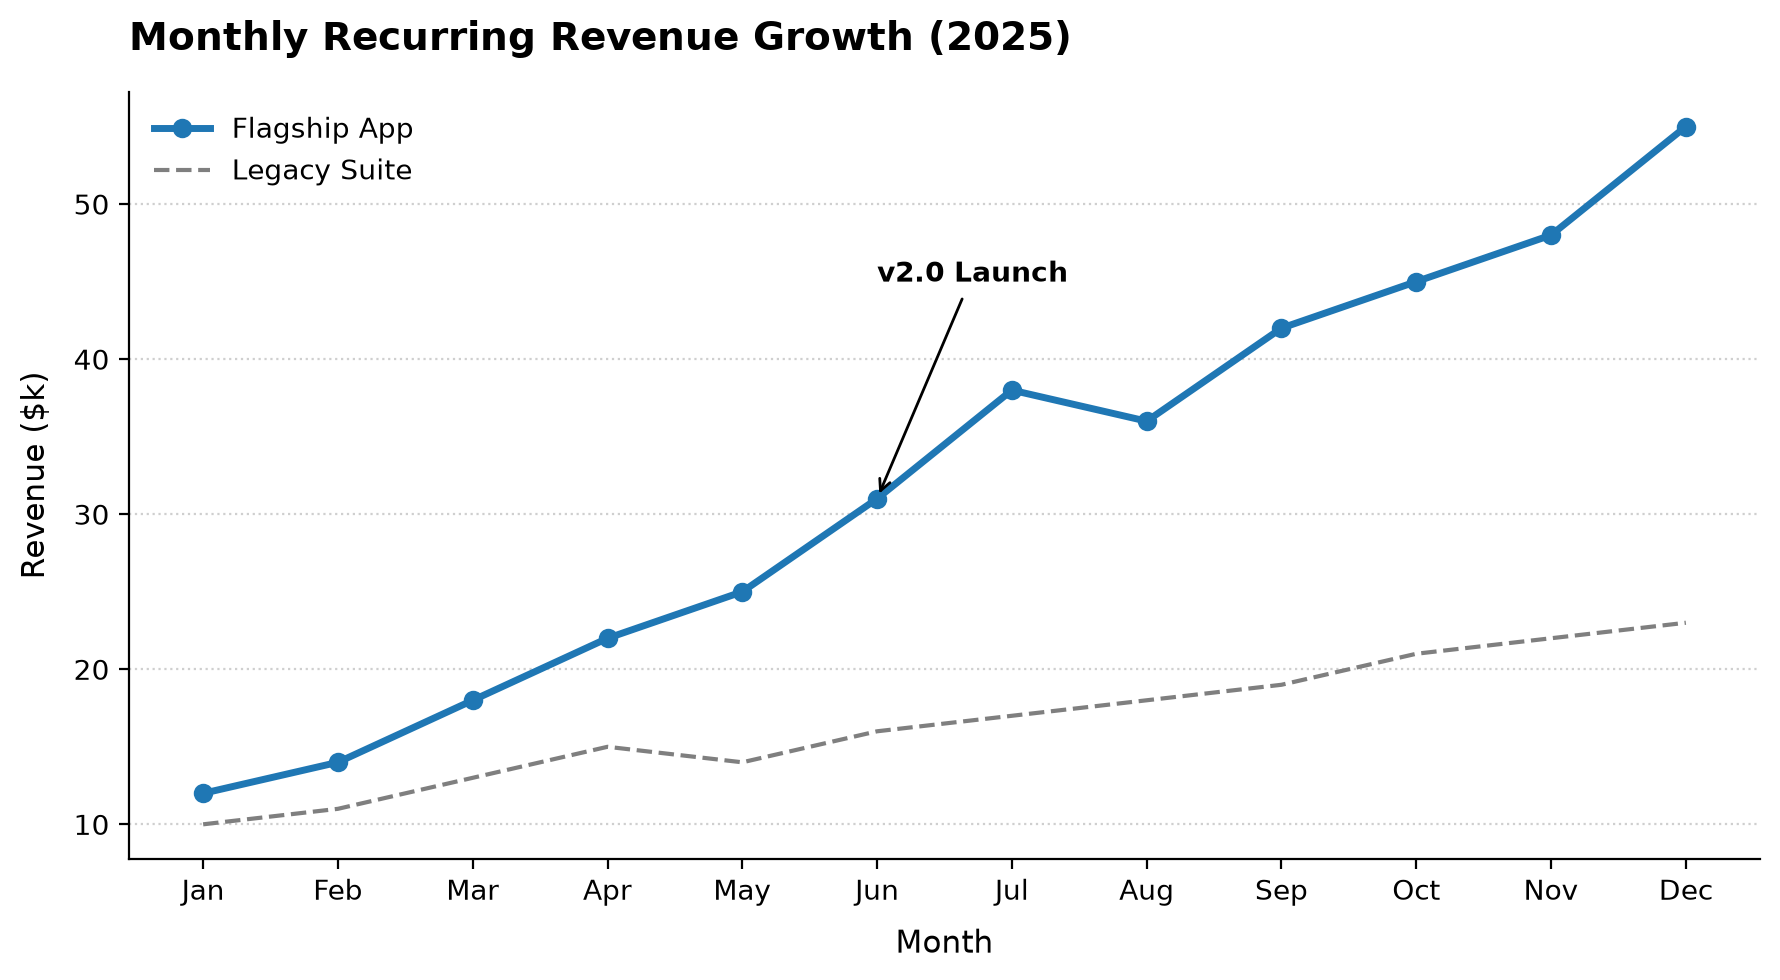

In [4]:
# Synthetic sales data across 12 months
months = np.arange(1, 13)
product_a = np.array([12, 14, 18, 22, 25, 31, 38, 36, 42, 45, 48, 55])
product_b = np.array([10, 11, 13, 15, 14, 16, 17, 18, 19, 21, 22, 23])

# 1. Initialize figure and axes
fig, ax = plt.subplots(figsize=(9, 5), dpi=200)

# 2. Plot data with distinct hierarchy
ax.plot(months, product_a, label="Flagship App", color="#1f77b4", linewidth=2.5, marker="o")
ax.plot(months, product_b, label="Legacy Suite", color="#7f7f7f", linewidth=1.5, linestyle="--")

# 3. Labeling and styling
ax.set_title("Monthly Recurring Revenue Growth (2025)", fontsize=14, pad=15, fontweight="bold", loc="left")
ax.set_xlabel("Month", fontsize=11, labelpad=8)
ax.set_ylabel("Revenue ($k)", fontsize=11, labelpad=8)
ax.set_xticks(months)
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

# 4. Contextual annotation highlighting a milestone
ax.annotate(
    "v2.0 Launch",
    xy=(6, 31),
    xytext=(6, 45),
    arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
    fontsize=10,
    fontweight="semibold"
)

# 5. Clean up non-data ink
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()

## Sample 2

C:\Users\esper\AppData\Local\Temp\ipykernel_25380\2139021444.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


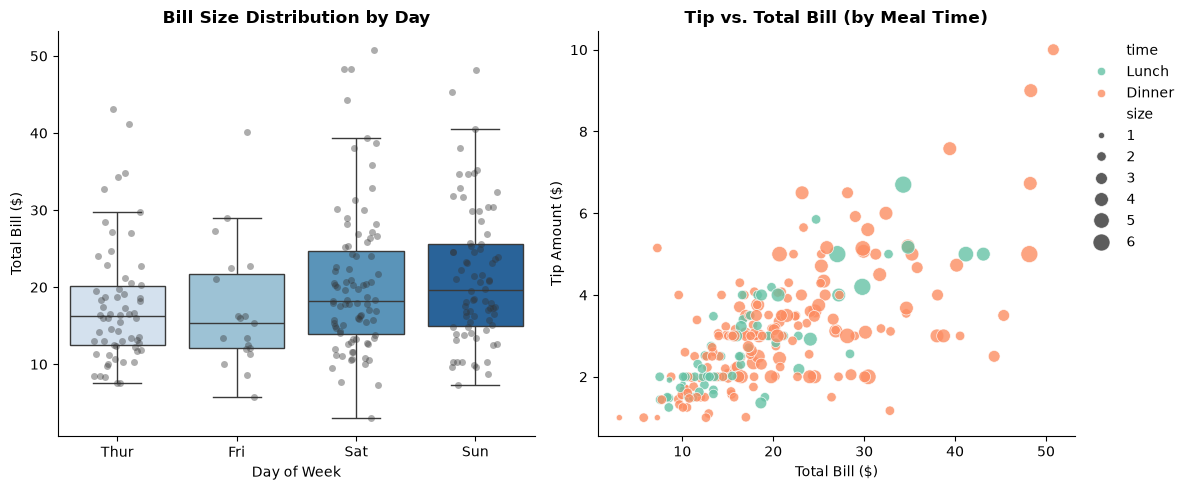

In [5]:
# Load a standard dataset
tips = sns.load_dataset("tips")

# 1. Create a 1-row, 2-column subplot grid
fig, (ax_box, ax_scatter) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# 2. Left panel: Seaborn boxplot with jittered strip points
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    palette="Blues",
    ax=ax_box,
    fliersize=0  # Hide outliers here to avoid double-plotting with stripplot
)
sns.stripplot(
    data=tips,
    x="day",
    y="total_bill",
    color="0.2",
    alpha=0.4,
    jitter=0.2,
    size=5,
    ax=ax_box
)
ax_box.set_title("Bill Size Distribution by Day", fontsize=12, fontweight="bold")
ax_box.set_xlabel("Day of Week")
ax_box.set_ylabel("Total Bill ($)")

# 3. Right panel: Seaborn scatter with categorical hue and size mapping
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="time",
    size="size",
    sizes=(20, 150),
    alpha=0.8,
    palette="Set2",
    ax=ax_scatter
)
ax_scatter.set_title("Tip vs. Total Bill (by Meal Time)", fontsize=12, fontweight="bold")
ax_scatter.set_xlabel("Total Bill ($)")
ax_scatter.set_ylabel("Tip Amount ($)")

# Move legend outside to prevent data occlusion
sns.move_legend(ax_scatter, "upper left", bbox_to_anchor=(1, 1), frameon=False)

# 4. Clean global layout
sns.despine(fig=fig)
plt.tight_layout()

## Sample 3

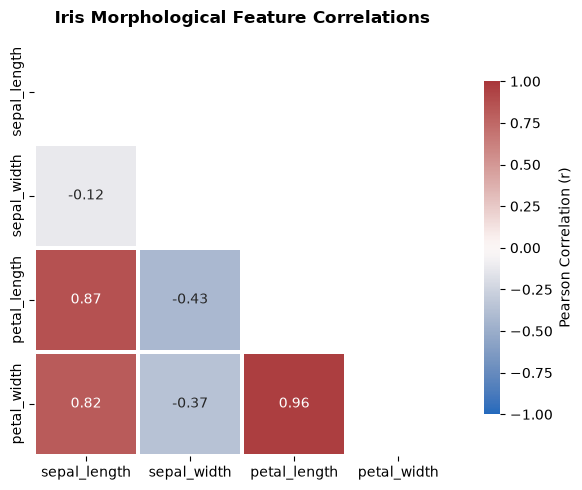

In [6]:
# Generate correlation matrix on numeric columns
df = sns.load_dataset("iris").drop(columns="species")
corr = df.corr()

# 1. Create a boolean mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# 2. Set up Matplotlib figure canvas
fig, ax = plt.subplots(figsize=(7, 5))

# 3. Draw heatmap with zero-centered diverging palette
sns.heatmap(
    corr,
    mask=mask,
    cmap="vlag",          # Diverging colormap: blue (negative) to red (positive)
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,           # Display numeric correlation coefficients
    fmt=".2f",
    square=True,          # Force cells to equal aspect ratio
    linewidths=1.5,       # Grid separation
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"},
    ax=ax
)

ax.set_title("Iris Morphological Feature Correlations", fontsize=12, pad=12, fontweight="bold")
plt.tight_layout()